# LSST SN Ia Simulation Pipeline

Forward-model SN Ia light curves with the lsstcam Science Validation cadence using `lightcurvelynx`.

**Survey**: lsstcam Science Validation visits (`lsstcam_20250930.db`)  
**Model**: SALT3 via `SncosmoWrapperModel`  
**Filters**: u, g, r, i, z, y  
**Redshift**: volumetric rate (Frohmaier et al. 2019), z = 0.01–1.2  
**Parameters**: Gaussian priors for x1 and c (no pzflow, no host galaxy)

## 1. Imports

## 0. Environment Setup

Set `LIGHTCURVELYNX_DATA_DIR` **before** importing lightcurvelynx — the download path is resolved at import time.  
Downloaded files (OpSim DB, passbands) will be stored in `./data/` inside this project directory.

In [1]:
# auto reload
%load_ext autoreload
%autoreload 2

In [2]:
import os
from pathlib import Path

# Store downloaded data inside this project so it travels with the repo checkout.
# Must be set before any lightcurvelynx imports (path is resolved at import time).
_data_dir = Path().resolve() / "data"
_data_dir.mkdir(exist_ok=True)
os.environ["LIGHTCURVELYNX_DATA_DIR"] = str(_data_dir)
print(f"LIGHTCURVELYNX_DATA_DIR = {_data_dir}")

LIGHTCURVELYNX_DATA_DIR = /Users/mi/Work/lightcurvelynx_rubin_dp2/data


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.stats import chi2
from nested_pandas import read_parquet
import loky
import sncosmo

from lightcurvelynx.obstable.lsst_obstable import LSSTObsTable
from lightcurvelynx.utils.io_utils import read_sqlite_table
from lightcurvelynx.astro_utils.passbands import PassbandGroup
from lightcurvelynx.astro_utils.snia_utils import (
    DistModFromRedshift,
    X0FromDistMod,
    num_snia_per_redshift_bin,
    snia_volumetric_rates,
)
from lightcurvelynx.math_nodes.np_random import NumpyRandomFunc
from lightcurvelynx.math_nodes.scipy_random import SamplePDF
from lightcurvelynx.math_nodes.ra_dec_sampler import ObsTableUniformRADECSampler,ApproximateMOCSampler
from lightcurvelynx.models.sncosmo_models import SncosmoWrapperModel
from lightcurvelynx.simulate import simulate_lightcurves
from lightcurvelynx.utils.extrapolate import LinearDecayOnMag,ZeroPadding
from lightcurvelynx.astro_utils.dustmap import DustmapWrapper,SFDMap
from lightcurvelynx.effects.extinction import ExtinctionEffect

## 2. Simulation Configuration

In [4]:
SEED = 1024
RNG  = np.random.default_rng(SEED)

SKIP_SIM = False   # Set to True to skip simulation and load existing results from disk.
SKIP_LCFIT = False # Set to True to skip LC fitting and load existing results from disk.

SIM_PARAMS = {
    # Cosmology
    "H0": 70.0,
    "Omega_m": 0.315,
    "w": -1.0,
    # Redshift range
    "zmin": 0.001,
    "zmax": 1.0,
    "znbins": 100,
    # Tripp relation coefficients
    "alpha": 0.15,
    "beta": 3.15,
    # SALT3 asymmetric Gaussian priors (Nicolas et al. 2021)
    "x1_mean": 0.973,  "x1_sigma_minus": 1.472, "x1_sigma_plus": 0.222,
    "c_mean": -0.054,  "c_sigma_minus":  0.043,  "c_sigma_plus":  0.101,
    "m_abs_mean": -19.3, "m_abs_sigma": 0.1,
    # Survey
    "filters": ["u", "g", "r", "i", "z", "y"],
    "sky_coverage": 18_000.0,  # LSST WFD footprint in deg²
}

## 3. Load LSST Visit Table

In [5]:
# _sv_table = read_sqlite_table(
#     "data/visittable/lsstcam_20250930.db",
#     sql_query="SELECT * FROM observations",
# )
# _sv_table_dd = _sv_table[_sv_table['observation_reason'].str.contains('ddf')]
dp1_visit_table = pd.read_parquet("data/visittable/ccd_visit_dp1.parquet")

obstable = LSSTObsTable.from_ccdvisit_table(dp1_visit_table,make_detector_footprint=False)
print(f"Visit table loaded: {len(obstable):,} observations")
print(f"MJD range: {obstable['time'].min():.1f} – {obstable['time'].max():.1f}")
print(f"Filters:    {sorted(obstable['filter'].unique())}")

Visit table loaded: 15,994 observations
MJD range: 60623.3 – 60656.4
Filters:    ['g', 'i', 'r', 'u', 'y', 'z']


/Users/mi/Work/lightcurvelynx/lightcurvelynx/src/lightcurvelynx/obstable/lsst_obstable.py:273: UserWarning: Found NaN values in critical column 'seeing'. Dropping rows with NaN values in this column.
  warnings.warn(
/Users/mi/Work/lightcurvelynx/lightcurvelynx/src/lightcurvelynx/obstable/lsst_obstable.py:310: UserWarning: Not creating a detector footprint for a CCD pointing table. This may lead to duplicate results for points near the edges of the CCDs.
  warnings.warn(


In [6]:
obstable.head()

,detectorId,visitId,physical_filter,filter,ra,dec,pixel_scale,zenithDistance,exptime,zp_mag_adu,...,ulcra,ulcdec,urcra,urcdec,lrcra,lrcdec,radius,zp,psf_footprint,sky_bg_e
0,0,2024110800245,i_06,i,53.004536,-28.190331,0.200343,15.811996,30.0,31.838995,...,52.910473,-28.054937,53.156342,-28.104861,53.098773,-28.325700,0.158788,0.418448,42.201962,2274.280273
1,1,2024110800245,i_06,i,53.064355,-27.961231,0.200280,15.809622,30.0,31.838730,...,52.970552,-27.825752,53.215842,-27.875887,53.158312,-28.096599,0.158738,0.418550,38.347035,2268.893799
2,2,2024110800245,i_06,i,53.123909,-27.731684,0.200342,15.810765,30.0,31.836647,...,53.029964,-27.596199,53.274910,-27.646045,53.217970,-27.866966,0.158787,0.419354,40.221183,2262.304932
3,3,2024110800245,i_06,i,53.264695,-28.242508,0.200274,15.576916,30.0,31.837961,...,53.170249,-28.107341,53.416250,-28.156717,53.359393,-28.377705,0.158733,0.418846,41.754855,2274.233643
4,4,2024110800245,i_06,i,53.323752,-28.013505,0.200218,15.574672,30.0,31.839149,...,53.229503,-27.878345,53.474983,-27.927729,53.418232,-28.148602,0.158689,0.418388,36.911712,2271.795410


In [7]:
sky_coverage = obstable.estimate_coverage(max_depth=12,use_footprint=True)    
# sky_coverage = 75
SIM_PARAMS["sky_coverage"] = sky_coverage
print(f"Estimated sky coverage: {sky_coverage:.0f} deg²")

Estimated sky coverage: 12 deg²


(<Figure size 640x480 with 1 Axes>, <WCSAxes: >)

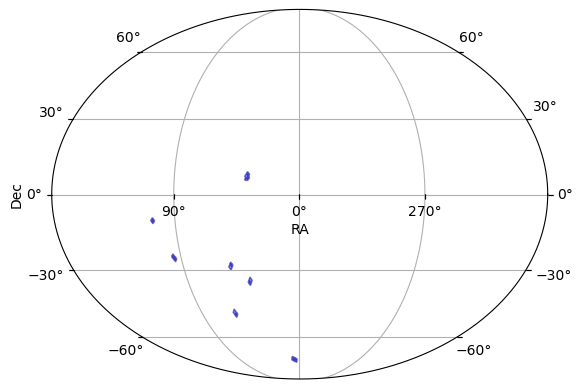

In [8]:
obstable.plot_footprint()

## 4. Calculate Number of SNe to Simulate

Integrate the volumetric SN Ia rate over the survey volume and duration:
$$N = \int_{z_{\rm min}}^{z_{\rm max}} r_v(z)\,\frac{dV}{dz}\,\frac{dz}{1+z} \times \Omega \times T_{\rm survey}$$

In [9]:
t_min = float(obstable["time"].min())
t_max = float(obstable["time"].max())

survey_length = (t_max - t_min) / 365.25
print(f"Survey length = {survey_length:.2f} years")

solid_angle = SIM_PARAMS["sky_coverage"] * (np.pi / 180.0) ** 2
print(f"Solid angle   = {solid_angle:.4f} sr  ({SIM_PARAMS['sky_coverage']:,.0f} deg²)")

nsntotal, _ = num_snia_per_redshift_bin(
    SIM_PARAMS["zmin"],
    SIM_PARAMS["zmax"],
    znbins=1,
    solid_angle=solid_angle,
    vol_rate_function=snia_volumetric_rates,
    H0=SIM_PARAMS["H0"],
    Omega_m=SIM_PARAMS["Omega_m"],
)
nsn = int(nsntotal[0] * survey_length)
print(f"Expected SNe Ia = {nsn:,}")

Survey length = 0.09 years
Solid angle   = 0.0035 sr  (12 deg²)
Expected SNe Ia = 122


## 5. Load LSST Passbands

In [10]:
passbands = PassbandGroup.from_preset("LSST", filters=SIM_PARAMS["filters"])
print(passbands)

PassbandGroup containing 6 passbands: LSST_u, LSST_g, LSST_r, LSST_i, LSST_z, LSST_y


## 6. Redshift Distribution (Volumetric Rate)

Use the Frohmaier et al. (2019) volumetric rate $r_v(z) = r_0\,(1+z)^\alpha$ to compute the
expected number of SNe Ia per redshift bin, then build an interpolated PDF for sampling.

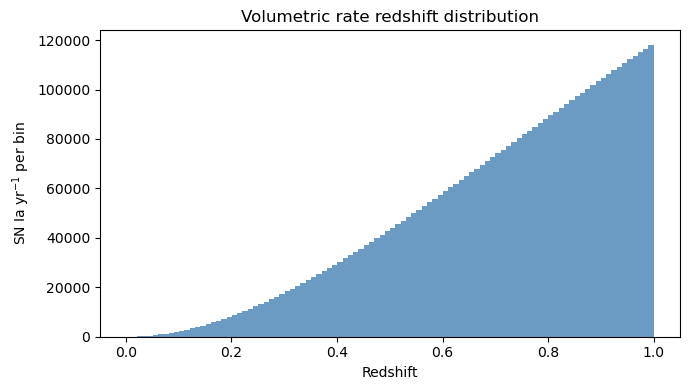

In [11]:
nsn_per_bin, z_mean = num_snia_per_redshift_bin(
    SIM_PARAMS["zmin"],
    SIM_PARAMS["zmax"],
    SIM_PARAMS["znbins"],
    H0=SIM_PARAMS["H0"],
    Omega_m=SIM_PARAMS["Omega_m"],
)
zpdf = interp1d(z_mean, nsn_per_bin, bounds_error=False, fill_value=0)

fig, ax = plt.subplots(figsize=(7, 4))
dz = (SIM_PARAMS["zmax"] - SIM_PARAMS["zmin"]) / SIM_PARAMS["znbins"]
ax.bar(z_mean, nsn_per_bin, width=dz, color="steelblue", alpha=0.8)
ax.set(xlabel="Redshift", ylabel="SN Ia yr$^{-1}$ per bin",
       title="Volumetric rate redshift distribution")
plt.tight_layout()
plt.show()

## 7. Build SN Ia Source Model

Parameter graph:
- **RA, Dec** — uniformly sampled from the observed LSST footprint (`ObsTableUniformRADECSampler`)
- **redshift** — drawn from the volumetric rate PDF (`SamplePDF`)
- **x1** — Gaussian($\mu=0$, $\sigma=1$)
- **c** — Gaussian($\mu=0$, $\sigma=0.1$)
- **M_abs** — Gaussian($\mu=-19.3$, $\sigma=0.12$)
- **distmod** — computed from redshift via `DistModFromRedshift`
- **x0** — computed via the Tripp relation through `X0FromDistMod`

In [12]:
# RA/Dec: uniform over the obstable footprint (rejection sampling)
# radec = ObsTableUniformRADECSampler(obstable, node_label="radec")
moc = obstable.build_moc(max_depth=12)
radec = ApproximateMOCSampler(moc, node_label="radec")

# Redshift from volumetric rate PDF
z_func = SamplePDF(zpdf, node_label="redshift")

# Asymmetric Gaussian priors for x1 and c (Nicolas et al. 2021)
def asymmetric_gaussian_pdf(x, mu, sigma_minus, sigma_plus):
    sigma = np.where(x < mu, sigma_minus, sigma_plus)
    return np.exp(-0.5 * ((x - mu) / sigma) ** 2)

def x1_pdf(x):
    return asymmetric_gaussian_pdf(x, SIM_PARAMS["x1_mean"],
                                   SIM_PARAMS["x1_sigma_minus"], SIM_PARAMS["x1_sigma_plus"])

def c_pdf(c):
    return asymmetric_gaussian_pdf(c, SIM_PARAMS["c_mean"],
                                   SIM_PARAMS["c_sigma_minus"], SIM_PARAMS["c_sigma_plus"])

x1_func    = SamplePDF(x1_pdf, node_label="x1")
c_func     = SamplePDF(c_pdf,  node_label="c")
m_abs_func = NumpyRandomFunc("normal", loc=SIM_PARAMS["m_abs_mean"], scale=SIM_PARAMS["m_abs_sigma"])

# x0 via Tripp relation
distmod_func = DistModFromRedshift(
    z_func, H0=SIM_PARAMS["H0"], Omega_m=SIM_PARAMS["Omega_m"]
)
x0_func = X0FromDistMod(
    distmod=distmod_func,
    x1=x1_func,
    c=c_func,
    alpha=SIM_PARAMS["alpha"],
    beta=SIM_PARAMS["beta"],
    m_abs=m_abs_func,
    node_label="x0_func",
)

# Extrapolation settings
time_extrap_before = ZeroPadding()
time_extrap_after = LinearDecayOnMag(decay_rate=0.02, mag_thres=30.)
wave_extrap_before = ZeroPadding()
wave_extrap_after = ZeroPadding()

# Assemble the SALT3 source (no host galaxy)
source = SncosmoWrapperModel(
    "salt3",
    t0=NumpyRandomFunc("uniform", low=t_min, high=t_max),
    x0=x0_func,
    x1=x1_func,
    c=c_func,
    ra=radec.ra,
    dec=radec.dec,
    redshift=z_func,
    node_label="source",
    time_extrapolation=(time_extrap_before, time_extrap_after),
    wave_extrapolation=(wave_extrap_before, wave_extrap_after),
)

from dustmaps.sfd import SFDQuery
mwextinction = DustmapWrapper(SFDQuery(), ra=source.ra, dec=source.dec, node_label="mwext")
ext_effect = ExtinctionEffect(extinction_model="F99", ebv=mwextinction,
                              r_v=3.1, frame='observer', backend="dust_extinction")
source.add_effect(ext_effect)

print("Source model built successfully.")

Source model built successfully.


## 8. Run Simulation

In [13]:
if not SKIP_SIM:
    param_cols = [
        "source.t0",
        "source.x0",
        "source.x1",
        "source.c",
        "source.redshift",
        "source.ra",
        "source.dec",
        "x0_func.distmod",
    ]
    obstable_save_cols = ["zp"]

    NJOBS = 8
    BATCH_SIZE = 3000
    executor = loky.get_reusable_executor(max_workers=4)
    lightcurves = simulate_lightcurves(
        model=source,
        num_samples=nsn,
        survey_info=obstable,
        passbands=passbands,
        param_cols=param_cols,
        obstable_save_cols=obstable_save_cols,
        rng=RNG,
        num_jobs=NJOBS,
        batch_size=BATCH_SIZE,
        executor=executor,
    )
    print(f"Simulated {len(lightcurves):,} SNe Ia")
    lightcurves.head()

/Users/mi/Work/lightcurvelynx/lightcurvelynx/src/lightcurvelynx/simulate.py:716: FutureWarning: The passbands argument is deprecated and will be removed from future versions.
  warnings.warn(
/Users/mi/Work/lightcurvelynx/lightcurvelynx/src/lightcurvelynx/simulate.py:728: FutureWarning: Passing ObsTable objects directly in survey_info is deprecated and will be removed in future versions. Please use SurveyInfo objects instead.
  warnings.warn(


Simulating:   0%|          | 0/122 [00:00<?, ?obj/s]

/Users/mi/Work/lightcurvelynx/lightcurvelynx/src/lightcurvelynx/simulate.py:444: UserWarning: Found duplicate observation times in a single survey. This may indicate an issue with the ObsTable.
  warnings.warn(
Simulating:  13%|█▎        | 16/122 [00:04<00:26,  3.96obj/s]

/Users/mi/Work/lightcurvelynx/lightcurvelynx/src/lightcurvelynx/simulate.py:444: UserWarning: Found duplicate observation times in a single survey. This may indicate an issue with the ObsTable.
  warnings.warn(
Simulating:  26%|██▌       | 32/122 [00:04<00:10,  8.75obj/s]

/Users/mi/Work/lightcurvelynx/lightcurvelynx/src/lightcurvelynx/simulate.py:444: UserWarning: Found duplicate observation times in a single survey. This may indicate an issue with the ObsTable.
  warnings.warn(
Simulating:  39%|███▉      | 48/122 [00:04<00:05, 13.96obj/s]

...

/Users/mi/Work/lightcurvelynx/lightcurvelynx/src/lightcurvelynx/simulate.py:444: UserWarning: Found duplicate observation times in a single survey. This may indicate an issue with the ObsTable.
  warnings.warn(
Simulating:  79%|███████▊  | 96/122 [00:05<00:00, 33.65obj/s]

/Users/mi/Work/lightcurvelynx/lightcurvelynx/src/lightcurvelynx/simulate.py:444: UserWarning: Found duplicate observation times in a single survey. This may indicate an issue with the ObsTable.
  warnings.warn(
Simulating:  92%|█████████▏| 112/122 [00:05<00:00, 33.71obj/s]

/Users/mi/Work/lightcurvelynx/lightcurvelynx/src/lightcurvelynx/simulate.py:444: UserWarning: Found duplicate observation times in a single survey. This may indicate an issue with the ObsTable.
  warnings.warn(
Simulating: 100%|██████████| 122/122 [00:06<00:00, 31.81obj/s]

Simulating: 100%|██████████| 122/122 [00:06<00:00, 19.68obj/s]

Simulated 122 SNe Ia


## 9. Save Results

In [14]:
if not SKIP_SIM:
    from pathlib import Path
    output_path = Path("outputs/lsst_snia_dp1_results.parquet")
    output_path.parent.mkdir(exist_ok=True)
    lightcurves.to_parquet(output_path)
    print(f"Saved to {output_path}")

Saved to outputs/lsst_snia_dp1_results.parquet


In [15]:
lightcurves = read_parquet("outputs/lsst_snia_dp1_results.parquet")

## 10. Apply Selections

In [16]:
# calculate detection flag
lightcurves = lightcurves.drop(columns=["params"])
lightcurves = lightcurves.dropna(subset=['lightcurve'])

print("Before applying detection: nsn=", len(lightcurves))
lightcurves['lightcurve.snr'] = lightcurves['lightcurve.flux']/lightcurves['lightcurve.fluxerr']
detection_snr_thres = 5.
lightcurves['lightcurve.detection_flag'] = lightcurves['lightcurve.snr'] > detection_snr_thres

# drop saturation
lightcurves_after_drop_sat = lightcurves.query("lightcurve.is_saturated==False").dropna(subset=['lightcurve'])
print("After droppoing saturation: nsn=", len(lightcurves_after_drop_sat))

lightcurves_after_detection = lightcurves_after_drop_sat.query("lightcurve.detection_flag == True").dropna(subset=['lightcurve'])
print("After applying detection: nsn=", len(lightcurves_after_detection))

Before applying detection: nsn= 118
After droppoing saturation: nsn= 118
After applying detection: nsn= 87


/Users/mi/anaconda3/envs/lightcurvelynx/lib/python3.11/site-packages/nested_pandas/nestedframe/core.py:1393: RuntimeWarning: Engine has switched to 'python' because numexpr does not support extension array dtypes. Please set your engine to python manually.
  answer = super().eval(expr, **kwargs)
/Users/mi/anaconda3/envs/lightcurvelynx/lib/python3.11/site-packages/nested_pandas/nestedframe/core.py:1393: RuntimeWarning: Engine has switched to 'python' because numexpr does not support extension array dtypes. Please set your engine to python manually.
  answer = super().eval(expr, **kwargs)


In [17]:
# define quality cuts for lightcurves
def lc_quality_cuts(flux,mjd,filter,z,t0,n_phases=7, n_before_peak=2, n_after_peak=3, n_bands=2):
    phases = np.floor((mjd - t0)/(1. + z))
    unique_phases,unique_idx = np.unique(phases,return_index=True)
    good_idx = (unique_phases >= -10) & (unique_phases<=40)
    pass_cut = len(unique_phases[good_idx]) >= n_phases
    if np.sum(good_idx) == 0:
        return {"pass_quality_cuts": False}
    pass_before = np.sum(unique_phases[good_idx] < 0) >= n_before_peak
    pass_after = np.sum(unique_phases[good_idx] > 0) >= n_after_peak
    pass_cut = len(unique_phases[good_idx]) >= n_phases
    pass_cut &= pass_before
    pass_cut &= pass_after
    pass_cut &= len(np.unique(filter[unique_idx][good_idx])) >= n_bands
    return {"pass_quality_cuts": pass_cut}

In [18]:
pass_quality_cut = lightcurves_after_detection.map_rows(
    lc_quality_cuts,
    columns=["lightcurve.flux", "lightcurve.mjd", "lightcurve.filter", "z", "t0"],
    row_container="args"
)
idx = pass_quality_cut.query("pass_quality_cuts == True").index
lightcurves_after_quality_cut = lightcurves_after_detection.loc[idx]
print("After quality cuts: nsn=", len(lightcurves_after_quality_cut))

lightcurves["pass_quality_cuts"] = False
lightcurves.loc[idx,"pass_quality_cuts"] = True

After quality cuts: nsn= 7


In [19]:
def count_duplicate_mjd(mjd):
    unique_mjd, counts = np.unique(mjd, return_counts=True)
    num_duplicates = np.sum(counts > 1)
    return num_duplicates
ndf = lightcurves_after_quality_cut.map_rows(count_duplicate_mjd, columns=["lightcurve.mjd"], row_container="args")
ndf.loc[ndf[0]>0]

,0
47,209
64,22
80,36
101,50
110,34
119,21


## 11. Diagnostics

Quick sanity checks on the simulated population.

In [20]:
results = lightcurves_after_quality_cut

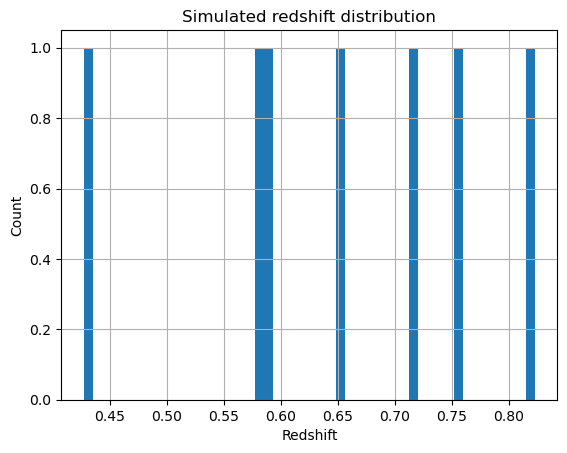

In [21]:
# redshift distribution of simulated SNe
fig, ax = plt.subplots()
results["source_redshift"].hist(bins=50, ax=ax)
ax.set(xlabel="Redshift", ylabel="Count", title="Simulated redshift distribution")
plt.show()

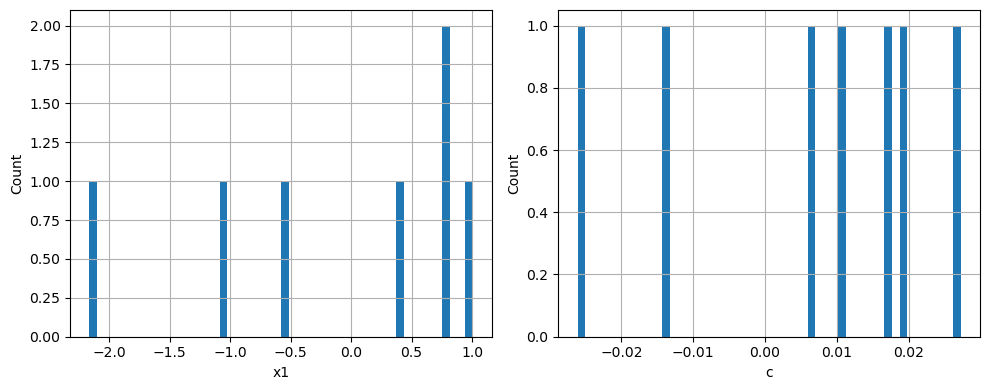

In [22]:
# x1 and c distributions
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
results["source_x1"].hist(bins=50, ax=axes[0])
axes[0].set(xlabel="x1", ylabel="Count")
results["source_c"].hist(bins=50, ax=axes[1])
axes[1].set(xlabel="c", ylabel="Count")
plt.tight_layout()
plt.show()

             mjd filter         flux     fluxerr  flux_perfect  survey_idx  \
0   60631.333894      i  1690.573359  239.488282   1569.415651           0   
1   60631.336425      z  2169.175403  403.463539   1524.149468           0   
..           ...    ...          ...         ...           ...         ...   
54  60654.238279      r  1441.424957  170.832184   1144.296251           0   
55  60654.242903      z  2528.585058  405.672978   1801.422559           0   

    obs_idx  is_saturated        zp       snr  detection_flag  
0      1401         False  0.424421  7.059107            True  
1      1419         False  0.602128  5.376385            True  
..      ...           ...       ...       ...             ...  
54    13918         False  0.371390  8.437666            True  
55    13999         False  0.629220  6.233063            True  

[56 rows x 11 columns]


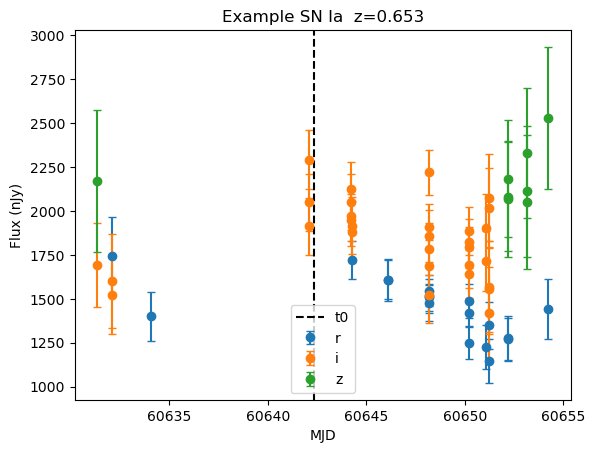

In [23]:
# example light curve for a single SN
sn = results.iloc[np.random.choice(len(results))]
lc = sn["lightcurve"]
print(lc)
for band in SIM_PARAMS["filters"]:
    mask = lc["filter"] == band
    mask &= (lc["mjd"] - sn["source_t0"])/(1. + sn["source_redshift"]) > -20  # only show points within 20 days before t0
    mask &= (lc["mjd"] - sn["source_t0"])/(1. + sn["source_redshift"]) < 100   # only show points within 20 days after t0
    if mask.any():
        plt.errorbar(lc["mjd"][mask], lc["flux"][mask], lc["fluxerr"][mask],
                     fmt="o", label=band, capsize=3)
plt.axvline(sn["source_t0"], ls="--", color="k", label="t0")
plt.legend()
plt.xlabel("MJD")
plt.ylabel("Flux (nJy)")
plt.title(f'Example SN Ia  z={sn["source_redshift"]:.3f}')
plt.show()

In [24]:
# append system path 

from utils.lcfit import fit_single_lc  

def fit_single_lc_w_cond(lc,
                         bounds={"x1": (-4,4),
                                 "c": (-0.4,0.4),},
                         phase_range=(-10,40),
                         modelcov=False):
    return fit_single_lc(lc,mpbounds=bounds,phase_range=phase_range,modelcov=modelcov)

In [25]:
res = fit_single_lc_w_cond(lightcurves_after_quality_cut.iloc[0])
res

success        1.0
ncall        166.0
             ...  
id            42.0
fit_error      NaN
Length: 54, dtype: float64

In [26]:
lc_to_fit = lightcurves_after_quality_cut.iloc[0:]

In [27]:
%%time
if not SKIP_LCFIT:
    executor = loky.get_reusable_executor(max_workers=10, kill_workers=True)
    futures = [executor.submit(fit_single_lc_w_cond, row) for _index, row in lc_to_fit.iterrows()]
    fit_results = [f.result() for f in futures]
    result_df = pd.DataFrame(fit_results)

CPU times: user 20.4 ms, sys: 73.5 ms, total: 93.9 ms
Wall time: 12.4 s


In [28]:
if not SKIP_LCFIT:
    result_df.to_csv("outputs/lsst_snia_dp1_lcfit_results.csv", index=True)
    print(f"Saved {len(result_df)} LC fit results")

Saved 7 LC fit results


In [29]:
saltparcuts = (result_df.x1 > -3) & (result_df.x1 < 3)
saltparcuts &= (result_df.c > -0.3) & (result_df.c < 0.3)
saltparcuts &= (result_df.success == True)
saltparcuts &= (result_df.t0_err < 1)
saltparcuts &= (result_df.x1_err < 1)
saltparcuts &= (result_df.c_err < 0.1)
p_value = 1 - chi2.cdf(result_df.chisq, df=result_df.ndof)
saltparcuts &= p_value > 1e-7

<Axes: >

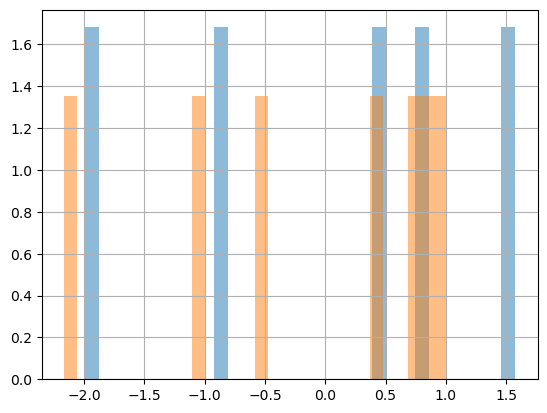

In [30]:
result_df[saltparcuts].x1.hist(bins=30,alpha=0.5,density=True)
lightcurves_after_quality_cut.source_x1.hist(bins=30,alpha=0.5,density=True)

<Axes: >

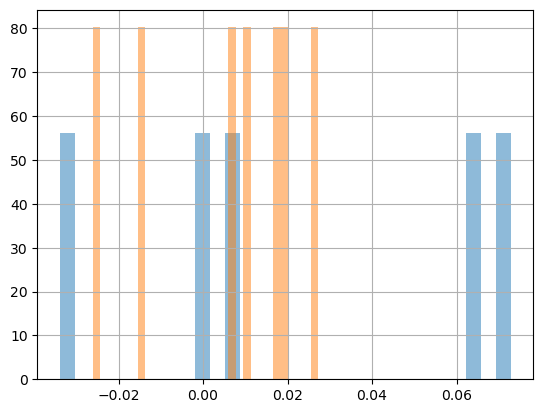

In [31]:
result_df[saltparcuts].c.hist(bins=30,alpha=0.5,density=True)
lightcurves_after_quality_cut.source_c.hist(bins=30,alpha=0.5,density=True)